In [6]:
import sys
!{sys.executable} -m pip install timesfm==1.2.9 huggingface_hub

In [7]:
import pandas as pd
import numpy as np
import timesfm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# 1. Load Data
df = pd.read_csv('../../../data/ds_data_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])
data_series = df['Daily User Installs'].values.astype(np.float32)
print(f"Data loaded: {len(data_series)} days")

Data loaded: 2313 days


In [8]:
# 2. Initialize TimesFM Model
tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        context_len=128,
        horizon_len=30,
        input_patch_len=32,
        output_patch_len=128,
        backend="torch",
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id="google/timesfm-1.0-200m-pytorch"
    ),
)
print("TimesFM model loaded successfully")

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 27715.67it/s]


TimesFM model loaded successfully


In [9]:
# 3. Train/Test Split + Forecast
train_series = data_series[:-30]
actuals = data_series[-30:]

forecast_input = [train_series]
forecast_output, _ = tfm.forecast(forecast_input, freq=[0])
predictions = forecast_output[0]

mae_timesfm = mean_absolute_error(actuals, predictions)
print(f"TimesFM Zero-Shot MAE: {mae_timesfm:.2f}")

TimesFM Zero-Shot MAE: 2787.69


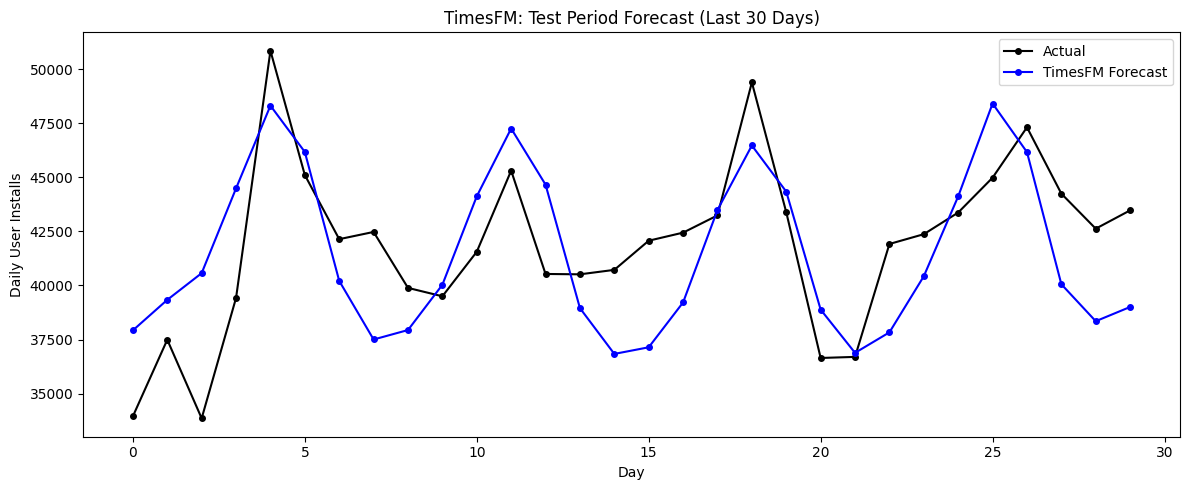

In [10]:
# 5. Zoomed test period plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(actuals, color='black', label='Actual', marker='o', markersize=4)
ax.plot(predictions, color='blue', label='TimesFM Forecast', marker='o', markersize=4)
ax.set_title('TimesFM: Test Period Forecast (Last 30 Days)')
ax.set_xlabel('Day')
ax.set_ylabel('Daily User Installs')
ax.legend()
plt.tight_layout()
plt.savefig('timesfm_test_forecast_plot.png')
plt.show()